# 1. Base Setup

## 1.1 Install packages

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!pip install kagglehub
!pip install statsmodels

## 1.2 Load all needed imports

In [3]:
from pathlib import Path

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV

from scipy.stats import randint
import sys, os
sys.path.append(os.path.abspath(".."))

/Users/anton/.pyenv/versions/3.10.6/envs/cf_copilot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data Cleaning and preprocessing


In [4]:
import cf_copilot
print(cf_copilot.__file__)

/Users/anton/code/DERNTOAN/cf_copilot/cf_copilot/__init__.py


In [5]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    """Load invoice dataset from local raw_data folder, or download from Kaggle.

    Args:
        csv_name: filename of the CSV to load.

    Returns:
        A pandas DataFrame with the raw invoice data.
    """
    base_dir = Path.cwd().parent
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",
    )

    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

In [6]:
from cf_copilot.ml_logic.data import data_cleaning, build_sliding_window_snapshots
from cf_copilot.ml_logic.encoders import preprocess, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from cf_copilot.ml_logic.model import initialize_model, train_model

hist_df = load_cashflow_data()

df = data_cleaning(hist_df)
big_df = build_sliding_window_snapshots(df)

big_df = big_df.sort_values("invoice_sent").reset_index(drop=True)
cutoff_date = big_df["invoice_sent"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df = big_df[big_df["reference_date"] > cutoff_date]

X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

pipeline = initialize_model()
pipeline = pipeline.fit(X_train, y_train)

Loading local file: /Users/anton/code/DERNTOAN/cf_copilot/raw_data/dataset.csv


/Users/anton/.pyenv/versions/3.10.6/envs/cf_copilot/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.6) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Saved model_df (39152 rows)
Original rows: 39152
Augmented rows: 98169
week_bucket
1    38825
2    33060
3    10401
4     4009
5     3172
6     2192
7     6510
Name: count, dtype: int64
✅ Model (pipeline) initialized


# 3. Feature selection

## 3.1 show feature importance

In [7]:
def show_feature_importance(pipeline):
    all_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    # Filter by which ones survived VarianceThreshold
    if "variance" in pipeline.named_steps:
        kept_mask = pipeline.named_steps["variance"].get_support()
        feature_names = all_names[kept_mask]
        feature_names = [name.split("__", 1)[1] for name in feature_names]
    else:
        feature_names = all_names


    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": pipeline.named_steps["classifier"].feature_importances_
    }).sort_values("importance", ascending=False)
    return importances

In [8]:
df = show_feature_importance(pipeline)
df

,feature,importance
6,num__days_past_due,0.190222
2,num__days_until_due,0.184114
1,num__invoice_age_days,0.089786
9,num__prev_transaction_count,0.086383
3,num__pay_terms_days,0.067584
11,num__customer_risk_score,0.065397
7,num__customer_avg_delay,0.063125
12,num__invoice_amount,0.047816
13,num__invoice_amount_log,0.047497
8,num__late_payment_ratio,0.047376



Evaluating model on 21811 rows...
✅ Log loss: 0.7894
✅ Top-1 accuracy: 0.7406
✅ Top-2 accuracy: 0.8872

Classification report:
              precision    recall  f1-score   support

           1       0.85      0.88      0.86      9647
           2       0.81      0.71      0.76      7578
           3       0.47      0.52      0.50      2170
           4       0.36      0.44      0.40       783
           5       0.39      0.38      0.38       554
           6       0.35      0.30      0.32       311
           7       0.53      0.69      0.60       768

    accuracy                           0.74     21811
   macro avg       0.54      0.56      0.54     21811
weighted avg       0.75      0.74      0.74     21811

Confusion matrix:
[[8470  606  279   91   47   17  137]
 [1215 5370  654  117   84   17  121]
 [ 154  562 1137  141   88   20   68]
 [  56   47  192  347   60   38   43]
 [  27   19   86  128  209   47   38]
 [  21    7   36   68   31   93   55]
 [  56   26   27   75   19   

{'metrics': {'log_loss': 0.7893971593133988,
  'top_1_accuracy': 0.7406354591719775,
  'top_2_accuracy': 0.8871670258126634,
  'forecast_mae_weekly': 1015698.4531818181,
  'forecast_mape_weekly': 0.649090909090909,
  'forecast_total_actual_cf': 30433551.419090904,
  'forecast_total_forecast_cf': 30111047.319999997,
  'forecast_total_cf_difference': -322504.09909090906},
 'figures': {'calibration_curves': <Figure size 1600x800 with 8 Axes>,
  'confusion_matrix': <Figure size 800x600 with 1 Axes>},
 'artifacts': {'classification_report.txt': '              precision    recall  f1-score   support\n\n           1       0.85      0.88      0.86      9647\n           2       0.81      0.71      0.76      7578\n           3       0.47      0.52      0.50      2170\n           4       0.36      0.44      0.40       783\n           5       0.39      0.38      0.38       554\n           6       0.35      0.30      0.32       311\n           7       0.53      0.69      0.60       768\n\n    accur

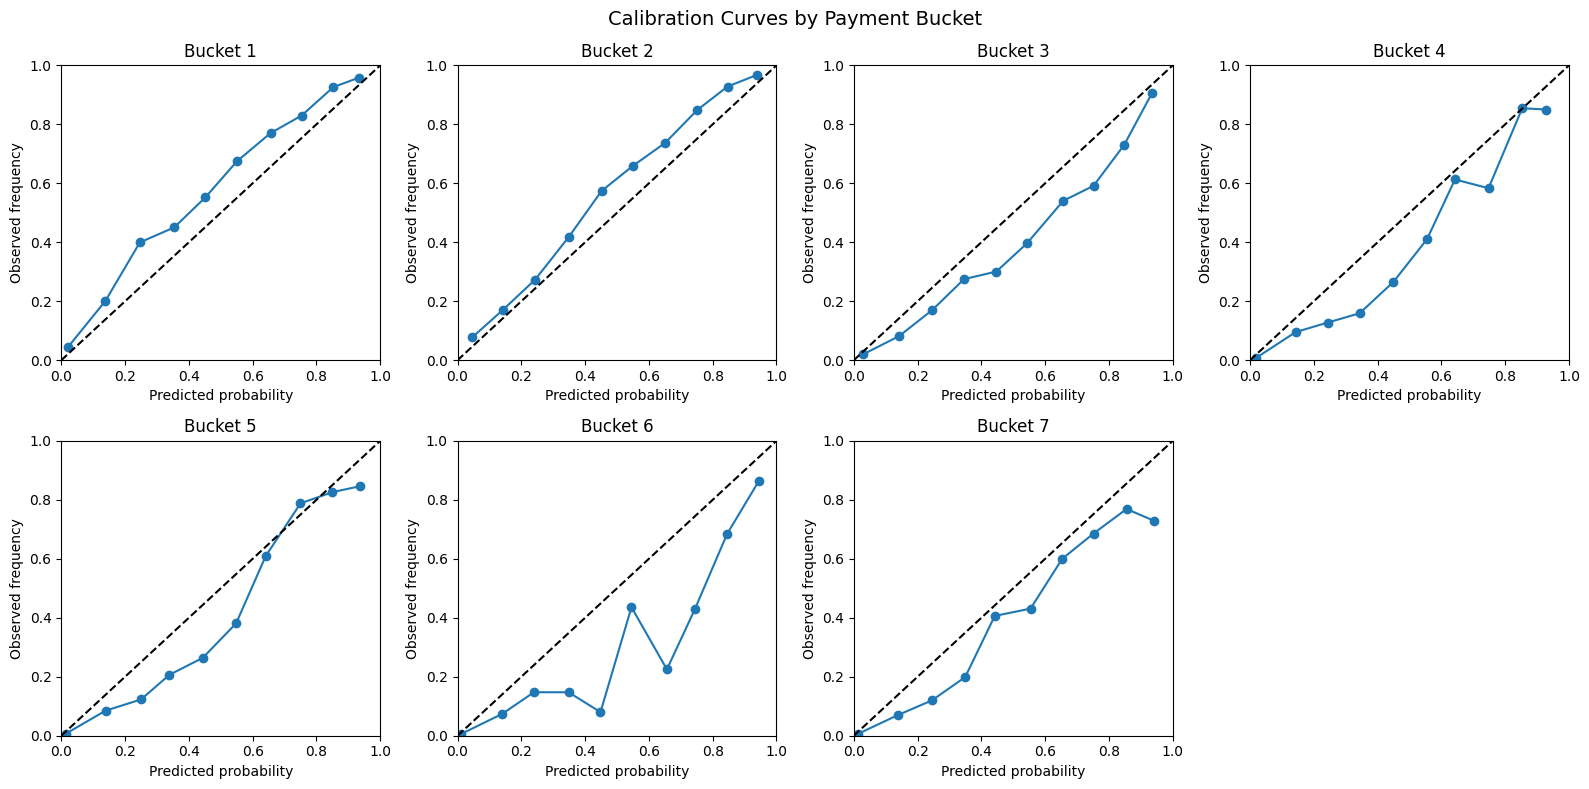

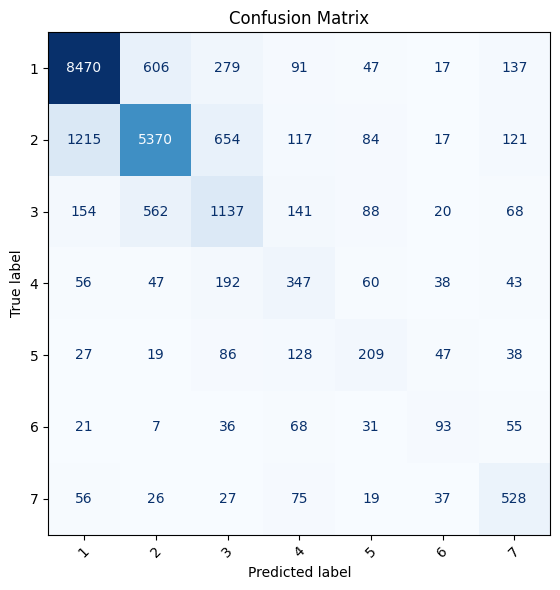

In [9]:
from cf_copilot.ml_logic.evaluation import evaluate_training_run

evaluate_training_run(pipeline=pipeline, X_test=X_test, y_test=y_test,
                                            test_df=test_df, big_df=big_df, log_backtests_to_mlflow=False
)

## 3.2  Add variance

In [10]:
from sklearn.feature_selection import VarianceThreshold

# Insert VarianceThreshold in existing pipeline, this drops near-constant features
new_pipeline = Pipeline([
    ("preprocessor", pipeline.named_steps["preprocessor"]),
    ("variance", VarianceThreshold(threshold=0.05)),
    ("classifier", pipeline.named_steps["classifier"]),
])
new_pipeline.fit(X_train, y_train)
show_feature_importance(new_pipeline)


,feature,importance
5,days_past_due,0.192583
1,days_until_due,0.183941
0,invoice_age_days,0.091334
8,prev_transaction_count,0.085059
2,pay_terms_days,0.065937
6,customer_avg_delay,0.064317
10,customer_risk_score,0.063931
11,invoice_amount,0.047646
12,invoice_amount_log,0.047444
7,late_payment_ratio,0.046350



Evaluating model on 21811 rows...
✅ Log loss: 0.7878
✅ Top-1 accuracy: 0.7388
✅ Top-2 accuracy: 0.8857

Classification report:
              precision    recall  f1-score   support

           1       0.84      0.88      0.86      9647
           2       0.81      0.71      0.75      7578
           3       0.48      0.52      0.50      2170
           4       0.35      0.45      0.40       783
           5       0.42      0.37      0.39       554
           6       0.34      0.30      0.32       311
           7       0.53      0.68      0.60       768

    accuracy                           0.74     21811
   macro avg       0.54      0.56      0.55     21811
weighted avg       0.75      0.74      0.74     21811

Confusion matrix:
[[8454  626  269   93   50   15  140]
 [1255 5343  652  118   78   16  116]
 [ 162  560 1139  158   63   20   68]
 [  58   53  185  352   52   41   42]
 [  27   20   86  127  207   47   40]
 [  22    7   33   71   31   93   54]
 [  57   27   25   77   17   

{'metrics': {'log_loss': 0.7878443025757639,
  'top_1_accuracy': 0.738755673742607,
  'top_2_accuracy': 0.8857457246343589,
  'forecast_mae_weekly': 1017110.5845454547,
  'forecast_mape_weekly': 0.6454545454545454,
  'forecast_total_actual_cf': 30433551.419090904,
  'forecast_total_forecast_cf': 30112657.778181817,
  'forecast_total_cf_difference': -320893.64090909093},
 'figures': {'calibration_curves': <Figure size 1600x800 with 8 Axes>,
  'confusion_matrix': <Figure size 800x600 with 1 Axes>},
 'artifacts': {'classification_report.txt': '              precision    recall  f1-score   support\n\n           1       0.84      0.88      0.86      9647\n           2       0.81      0.71      0.75      7578\n           3       0.48      0.52      0.50      2170\n           4       0.35      0.45      0.40       783\n           5       0.42      0.37      0.39       554\n           6       0.34      0.30      0.32       311\n           7       0.53      0.68      0.60       768\n\n    accur

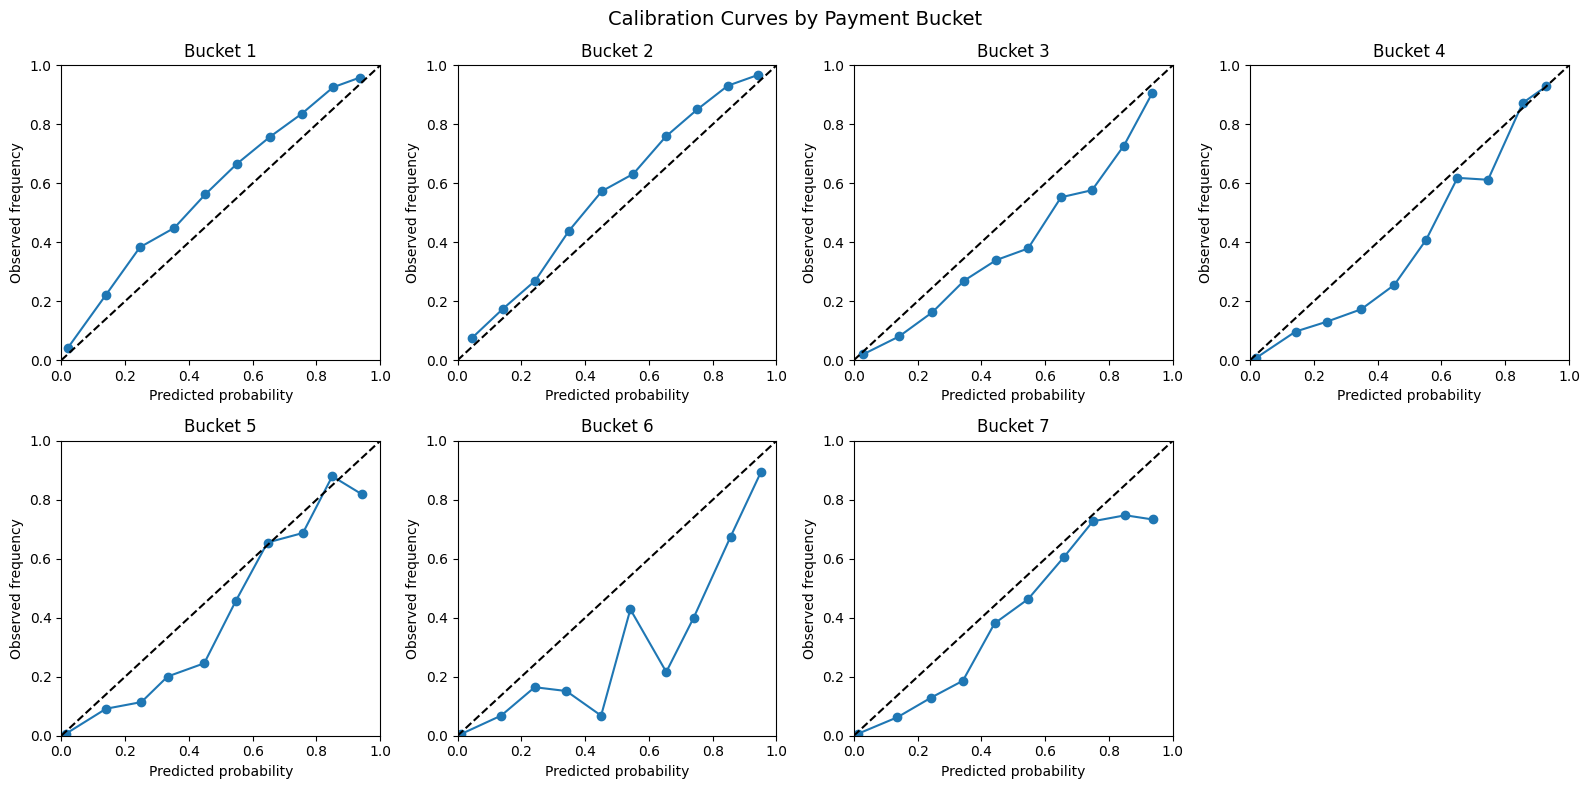

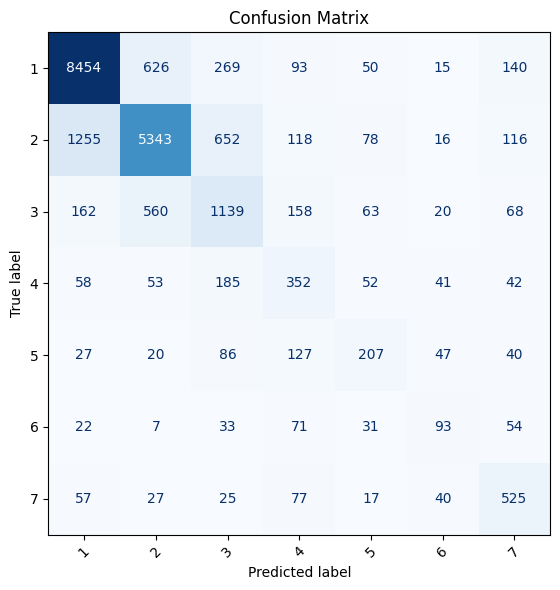

In [11]:
evaluate_training_run(pipeline=new_pipeline, X_test=X_test, y_test=y_test,
                                            test_df=test_df, big_df=big_df, log_backtests_to_mlflow=False
)

## 3.3 Permutation importance

### Permutation Importance — What does it mean?

Permutation importance works by shuffling one feature at a time and checking how much the model's performance drops. If the score drops a lot, that feature is important. If nothing changes, the feature isn't doing anything useful.

How to read the values:
- **importance_mean > 0** (e.g. 0.05): shuffling this feature made the model worse by 0.05. Good — it means the feature matters. Higher = more important.
- **importance_mean ≈ 0** (e.g. 0.001): the feature barely contributes anything. Could probably drop it.
- **importance_mean < 0** (e.g. -0.01): the model actually got *better* when we shuffled this feature. It's just adding noise — should definitely drop it.

importance_std shows how stable the result is across repeats. If importance_std is bigger than importance_mean, the result isn't very reliable and we can't really trust that feature's score.

One thing to watch out for: if two features are highly correlated, they'll both show lower importance than expected because shuffling one still leaves the other intact. So it's worth checking multicollinearity before drawing conclusions from this.

We're using X_test here instead of X_train to avoid overfit features looking more important than they actually are.

In [12]:
from sklearn.inspection import permutation_importance
X_pre = pipeline.named_steps["preprocessor"].fit_transform(X_train, y_train)

perm = permutation_importance(new_pipeline, X_train, y_train, n_repeats=10, scoring='neg_log_loss')

In [13]:
feature_names = new_pipeline.named_steps["preprocessor"].get_feature_names_out()

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
8,num__late_payment_ratio,3.963175e-01,8.492214e-04
4,num__invoice_month,3.819798e-01,9.046491e-04
3,num__pay_terms_days,2.565907e-01,3.624492e-04
5,num__due_month,2.177629e-01,3.591108e-04
12,num__invoice_amount,1.862242e-01,3.560977e-04
11,num__customer_risk_score,1.854560e-01,6.689022e-04
9,num__prev_transaction_count,1.785385e-01,4.719270e-04
10,num__days_since_last_invoice,1.726934e-01,6.439630e-04
14,cat__invoice_currency,9.064984e-02,1.635453e-04
15,cat__document_type,8.935199e-02,1.713465e-04


## 3.4 Automatic feature selection with CrossValidate

### RFECV — Recursive Feature Elimination with Cross Validation

RFECV works by repeatedly removing the least important feature, refitting the model each time, and checking the cross-validated score. It keeps doing this until it finds the smallest set of features that still gives the best performance.

How to read the results:
- **rfecv.n_features_**: the optimal number of features it found.
- **rfecv.support_**: a boolean mask showing which features were kept (True) and which were dropped (False).
- **rfecv.ranking_**: ranking per feature — 1 means it was selected, higher numbers mean it was eliminated earlier.
- **rfecv.cv_results_["mean_test_score"]**: the CV score at each step, useful to plot and see where performance peaks.



If the curve flattens out early, it means a lot of features aren't really helping and we can safely use a smaller set. If it keeps climbing until the end, we probably need all of them.

In [ ]:
# This takes quite some time with our current number of features, so be aware

from sklearn.feature_selection import RFECV
X_pre = pipeline.named_steps["preprocessor"].fit_transform(X_train, y_train)

rfecv = RFECV(
    estimator=pipeline.named_steps["classifier"],
    step=1,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
rfecv.fit(X_pre, y_train)
X_selected = rfecv.transform(X_train)

rfecv_df = pd.DataFrame({
    "feature": feature_names,
    "selected": rfecv.support_,
    "ranking": rfecv.ranking_,
}).sort_values("ranking")

rfecv_df

Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.


In [ ]:
X_selected.head()

# 4. Multicoliniarity

How to interpret VIF:

- VIF < 5 → fine
- VIF 5–10 → moderate, keep an eye on it
- VIF > 10 → strong multicollinearity, consider dropping one of the correlated pair

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_pre = pipeline.named_steps["preprocessor"].transform(X_train)
feature_names = [n.split("__", 1)[1] for n in pipeline.named_steps["preprocessor"].get_feature_names_out()]

vif_df = pd.DataFrame({
    "feature": feature_names,
    "VIF": [variance_inflation_factor(X_pre, i) for i in range(X_pre.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df